In [1]:
## Mounting Google Drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
## Loading libraries

!pip install gensim
!pip install numpy==1.25.0 # A known stable version for many setups
import numpy as np
import string
import os
import re
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk
from gensim.models import Word2Vec
from random import seed, shuffle
from gensim.models.callbacks import CallbackAny2Vec
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 33.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [3]:
## Loading our ensemble of 10 Word2Vec models
import numpy as np
from gensim.models import KeyedVectors

n_runs = 10
models = []

for run in range(1, n_runs + 1):
    path = f"/content/drive/MyDrive/vaccine data/SA_vaccine-total-platform_100_run{run}.emb"
    kv = KeyedVectors.load(path)
    models.append(kv)

print(f"Loaded {len(models)} embeddings")
print(models[0].vector_size)

Loaded 10 embeddings
200


=== WORD COVERAGE AUDIT ===

Race dimension keywords:
  MISSING 'afro' in run(s): [1, 2, 3, 5, 6, 9, 10]
  MISSING 'settler' in run(s): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  MISSING 'afrikaner' in run(s): [3, 4, 6, 9]

Stereotype terms:
  MISSING 'rude' in run(s): [4, 5]
  MISSING 'oppressive' in run(s): [1, 2, 6, 7]
  MISSING 'prejudiced' in run(s): [2, 3, 4, 5, 6, 8, 9]
  MISSING 'cultured' in run(s): [1, 2, 3, 4, 6, 7, 8, 10]
  MISSING 'tolerant' in run(s): [2, 3, 4, 6, 9]
  MISSING 'hypocritical' in run(s): [2, 3, 4, 7]
  MISSING 'intolerant' in run(s): [1, 3, 8, 10]
  MISSING 'hospitable' in run(s): [1, 2, 5, 6, 7, 8, 9, 10]
  MISSING 'exploitative' in run(s): [3, 4, 5, 6, 8, 9, 10]
  MISSING 'estates' in run(s): [1, 2, 3, 4, 5, 6, 8, 9, 10]
  MISSING 'elitist' in run(s): [6, 9]
  MISSING 'sheltered' in run(s): [4, 5, 7, 8, 9, 10]
  MISSING 'landowners' in run(s): [1, 2, 3, 4, 6, 10]
  MISSING 'underdeveloped' in run(s): [9]
  MISSING 'polluted' in run(s): [1, 3, 4, 5]
  MISSING 'uned

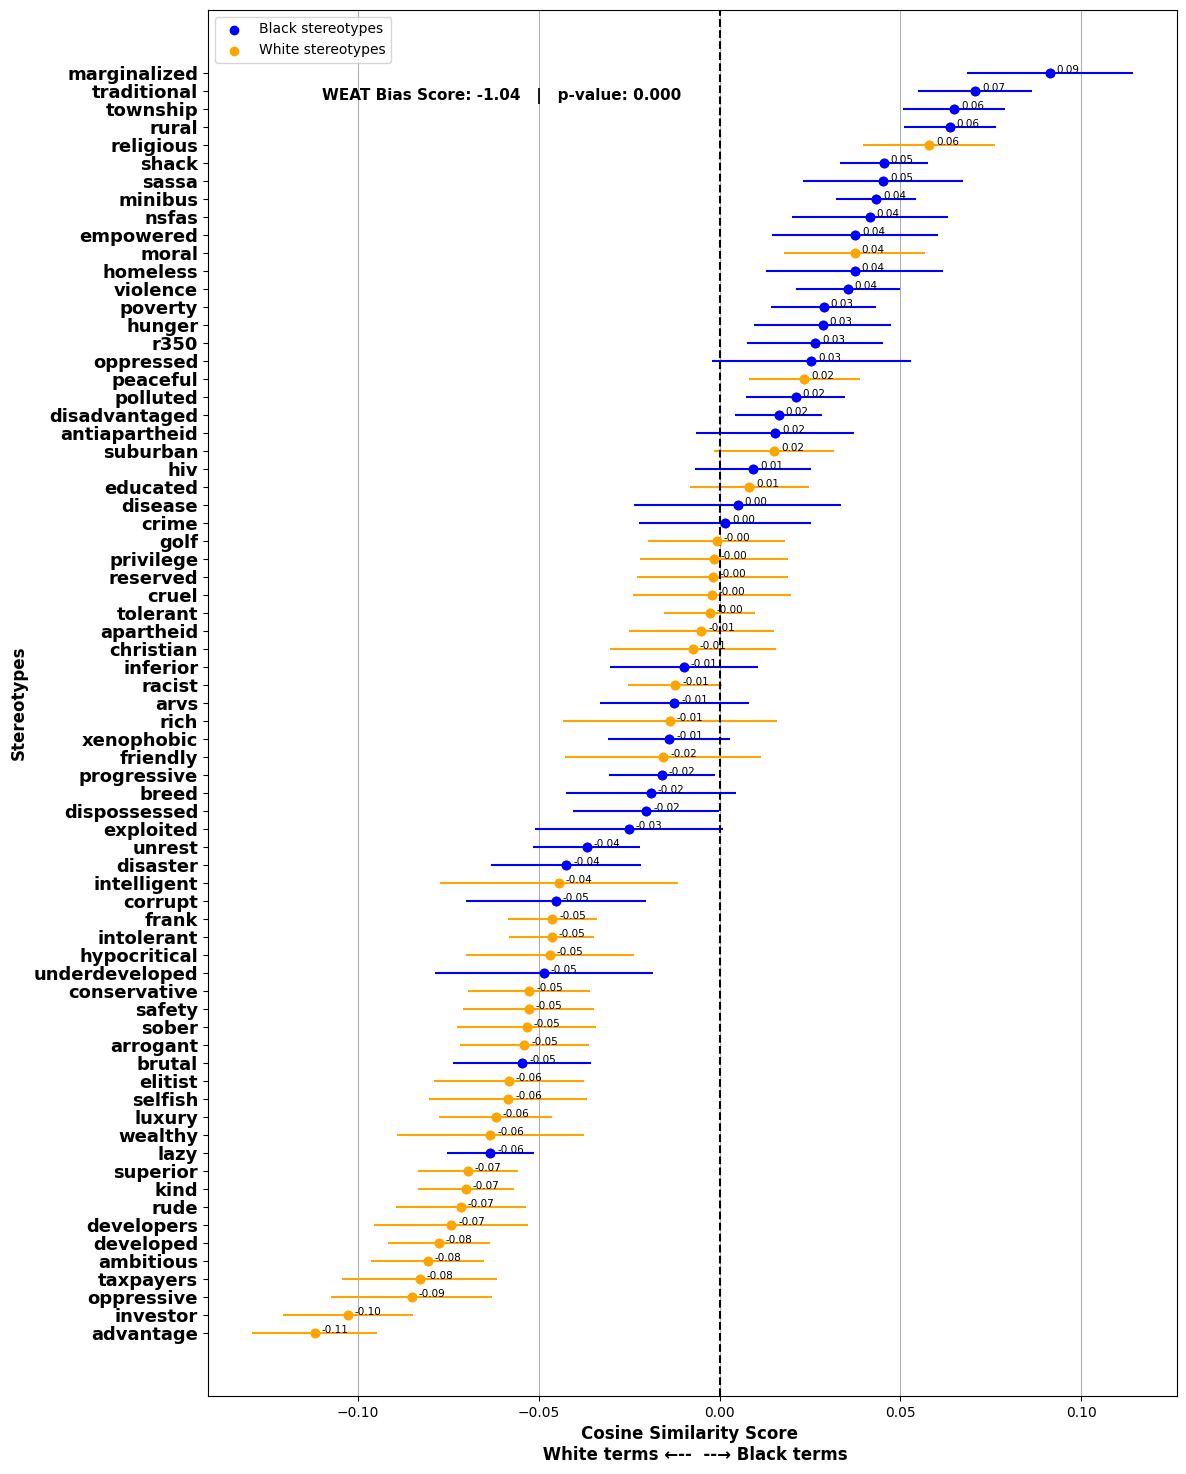


Results saved to: /content/drive/MyDrive/vaccine data/stereotype_cosine_similarity_platform_resampled_socioeconomic_100.xlsx


In [4]:
## Association between stereotypes and race dimensions (100 cap news articles)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import permutation_test
from collections import defaultdict

# ── Stereotype lists (unchanged from Ohamadike et al., 2025) ─────────────────
white_stereotypes = [
    "racist", "rude", "arrogant", "selfish", "wealthy", "oppressive",
    "prejudiced", "frank", "cultured", "friendly", "kind", "educated",
    "tolerant", "intelligent", "hypocritical", "advantage", "christian", "intolerant",
    "hospitable", "religious", "conservative", "reserved", "privilege", "exploitative",
    "estates", "elitist", "peaceful", "golf", "rich",
    "luxury", "sheltered", "apartheid", "ambitious", "investor", "developed",
    "sober", "safety", "suburban", "superior", "taxpayers", "landowners",
    "developers", "cruel", "moral"
]

black_stereotypes = [
    "underdeveloped", "violence", "crime", "polluted", "disadvantaged",
    "traditional", "empowered", "uneducated", "oppressed", "marginalized",
    "lazy", "rural", "corrupt", "shack", "township", "minibus",
    "hiv", "xenophobic", "looter", "alcoholism", "poverty", "exploited", "unrest",
    "nsfas", "sassa", "spaza", "homeless", "discriminated",
    "antiapartheid", "gardener", "arvs", "nyaope", "dispossessed", "inferior",
    "leech", "brutal", "barbaric", "squalor", "hunger", "r350", "progressive",
    "breed", "disease", "disaster"
]

all_stereotypes = white_stereotypes + black_stereotypes

race_groups = {
    "black_group":  ["black", "blacks", "african", "afro", "indigenous", "zulu"],
    "white_group":  ["white", "whites", "european", "american", "anglo", "settler", "afrikaner"]
}

MIN_RUNS = 5   # word must appear in at least this many runs to be included

# ── Word coverage audit ───────────────────────────────────────────────────────
print("=== WORD COVERAGE AUDIT ===")
for label, wordlist in [
    ("Race dimension keywords", race_groups["black_group"] + race_groups["white_group"]),
    ("Stereotype terms", all_stereotypes)
]:
    missing = defaultdict(list)
    for word in wordlist:
        absent_in = [i + 1 for i, m in enumerate(models) if word not in m]
        if absent_in:
            missing[word] = absent_in
    print(f"\n{label}:")
    if missing:
        for word, runs in missing.items():
            print(f"  MISSING '{word}' in run(s): {runs}")
    else:
        print("  All words present in all 10 models ✓")

# ── Centroid + normalised bias direction ─────────────────────────────────────
def compute_centroid(words, models):
    all_vectors = []
    for word in words:
        for model in models:
            if word in model:
                all_vectors.append(model[word])
    if not all_vectors:
        raise ValueError(f"None of {words} found in any model.")
    return np.mean(all_vectors, axis=0)

black_centroid = compute_centroid(race_groups["black_group"], models)
white_centroid = compute_centroid(race_groups["white_group"], models)
raw_direction  = black_centroid - white_centroid
bias_direction = raw_direction / np.linalg.norm(raw_direction)

# ── Per-stereotype cosine similarities ───────────────────────────────────────
def cosine_sim(vec, direction):
    return np.dot(vec, direction) / (np.linalg.norm(vec) * np.linalg.norm(direction))

stereotype_scores = {}
excluded = {"too_rare": [], "all_missing": []}

for word in all_stereotypes:
    run_sims = [cosine_sim(model[word], bias_direction)
                for model in models if word in model]
    n = len(run_sims)
    if n == 0:
        excluded["all_missing"].append(word)
    elif n < MIN_RUNS:
        excluded["too_rare"].append((word, n))
    else:
        stereotype_scores[word] = np.array(run_sims)

print(f"\n=== EXCLUSIONS (threshold: present in ≥{MIN_RUNS}/10 runs) ===")
print(f"Excluded (missing from all runs):        {excluded['all_missing']}")
print(f"Excluded (present in <{MIN_RUNS} runs):         "
      f"{[w for w, _ in excluded['too_rare']]}")
print(f"Retained for analysis: {len(stereotype_scores)}/{len(all_stereotypes)} terms")

stereotype_stats = {
    word: {
        "mean":   scores.mean(),
        "sd":     scores.std(),
        "se":     scores.std() / np.sqrt(len(scores)),
        "n_runs": len(scores)
    }
    for word, scores in stereotype_scores.items()
}

# ── WEAT ─────────────────────────────────────────────────────────────────────
def compute_weat(white_words, black_words, stereotype_scores):
    white_means = np.array([stereotype_scores[w].mean()
                            for w in white_words if w in stereotype_scores])
    black_means = np.array([stereotype_scores[w].mean()
                            for w in black_words  if w in stereotype_scores])
    combined    = np.concatenate([white_means, black_means])
    effect_size = (white_means.mean() - black_means.mean()) / combined.std()

    def stat_func(x, y, axis):
        return np.mean(x, axis=axis) - np.mean(y, axis=axis)

    result = permutation_test(
        (white_means, black_means),
        statistic=stat_func,
        n_resamples=10000,
        alternative="two-sided"
    )
    return effect_size, result.pvalue

effect_size, p_value = compute_weat(
    white_stereotypes, black_stereotypes, stereotype_scores
)
print(f"\n=== WEAT RESULTS ===")
print(f"Effect size (d): {effect_size:.3f}")
print(f"p-value:         {p_value:.4f}")
print(f"White terms in analysis: {sum(w in stereotype_scores for w in white_stereotypes)}")
print(f"Black terms in analysis: {sum(w in stereotype_scores for w in black_stereotypes)}")

# ── Plot (original design) ────────────────────────────────────────────────────
sorted_words = sorted(stereotype_scores.keys(),
                      key=lambda w: stereotype_stats[w]["mean"])
mean_scores  = [stereotype_stats[w]["mean"] for w in sorted_words]
std_errors   = [stereotype_stats[w]["se"]   for w in sorted_words]  # SE for bars

plt.figure(figsize=(12.5, 18))

# Scatter points — original colours
plt.scatter(
    [mean_scores[i] for i, w in enumerate(sorted_words) if w in black_stereotypes],
    [i              for i, w in enumerate(sorted_words) if w in black_stereotypes],
    color='blue', label='Black stereotypes', marker='o'
)
plt.scatter(
    [mean_scores[i] for i, w in enumerate(sorted_words) if w in white_stereotypes],
    [i              for i, w in enumerate(sorted_words) if w in white_stereotypes],
    color='orange', label='White stereotypes', marker='o'
)

# Error bars and annotations — original style
for i, word in enumerate(sorted_words):
    color = 'orange' if word in white_stereotypes else 'blue'
    plt.errorbar(mean_scores[i], i, xerr=std_errors[i],
                 fmt='o', color=color)
    plt.annotate(f'{mean_scores[i]:.2f}',
                 (mean_scores[i], i),
                 textcoords="offset points", xytext=(5, 0),
                 ha='left', fontsize=7.5)

plt.xlabel('Cosine Similarity Score \n White terms ←--  --→ Black terms',
           fontweight='bold', fontsize='large')
plt.ylabel('Stereotypes', fontweight='bold', fontsize=12)
plt.yticks(range(len(sorted_words)), sorted_words, fontweight='bold', fontsize=13)
plt.grid(axis='x')
plt.axvline(x=0, linestyle='--', color='black')
plt.legend(loc='upper left')

bias_text = f"WEAT Bias Score: {effect_size:.2f}   |   p-value: {p_value:.3f}"
plt.figtext(0.36, 0.83, bias_text, wrap=True,
            horizontalalignment='center', fontsize=11, fontweight='bold')

#plt.tight_layout()
#plt.show()

# Save plot
plot_path = '/content/drive/MyDrive/vaccine data/socioeconomic_stereotypes_platform_resampled_100.png'
plt.savefig(plot_path, bbox_inches='tight', dpi=700)
plt.show()

# ── Export ────────────────────────────────────────────────────────────────────
output_rows = []
for word in all_stereotypes:
    if word in stereotype_stats:
        s = stereotype_stats[word]
        output_rows.append({
            "Stereotype":             word,
            "Category":               "White" if word in white_stereotypes else "Black",
            "Mean Cosine Similarity": round(s["mean"], 4),
            "SD (cross-run)":         round(s["sd"],   4),
            "SE (cross-run)":         round(s["se"],   4),
            "N Runs":                 s["n_runs"]
        })

output_df = pd.DataFrame(output_rows)
output_path = "/content/drive/MyDrive/vaccine data/stereotype_cosine_similarity_platform_resampled_socioeconomic_100.xlsx"
output_df.to_excel(output_path, index=False)
print(f"\nResults saved to: {output_path}")

Stereotypes in analysis file:        71
Stereotypes with human ratings:      71
Missing human ratings (excluded):    set()

Pearson r = 0.612, p = 0.0000


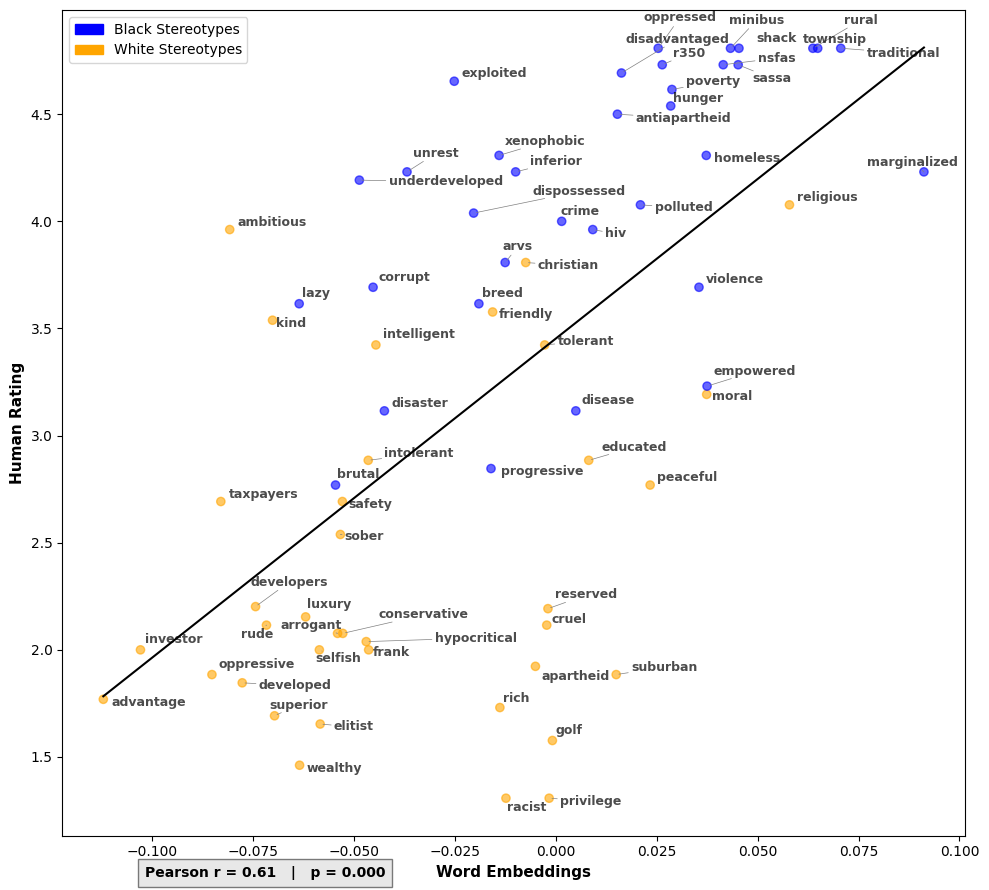


Plot saved to: /content/drive/MyDrive/vaccine data/socioeconomic_human_correlation_resampled_100.png


In [5]:
## Correlation between embeddings and human ratings (100 cap news articles)

!pip install adjustText
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from adjustText import adjust_text
import matplotlib.patches as mpatches

# ── Load only the stereotypes that passed MIN_RUNS threshold ─────────────────
results_path = '/content/drive/MyDrive/vaccine data/stereotype_cosine_similarity_platform_resampled_socioeconomic_100.xlsx'
data = pd.read_excel(results_path)

# Separate into category lists (based on Category column saved earlier)
white_stereotypes = data[data['Category'] == 'White']['Stereotype'].tolist()
black_stereotypes = data[data['Category'] == 'Black']['Stereotype'].tolist()

# ── Load human ratings and merge ─────────────────────────────────────────────
# Human ratings file must have columns: 'Adjective' and 'human_rating'
human_path = '/content/drive/My Drive/adjective_cosine_similarity_new1.xlsx'
human_data = pd.read_excel(human_path)

# Merge on stereotype name — keeps only stereotypes present in BOTH files
merged = data.merge(
    human_data[['Adjective', 'human_rating']],
    left_on='Stereotype',
    right_on='Adjective',
    how='inner'
).dropna(subset=['human_rating', 'Mean Cosine Similarity'])

print(f"Stereotypes in analysis file:        {len(data)}")
print(f"Stereotypes with human ratings:      {len(merged)}")
print(f"Missing human ratings (excluded):    "
      f"{set(data['Stereotype']) - set(merged['Stereotype'])}")

# ── Correlation ───────────────────────────────────────────────────────────────
correlation, p_value = pearsonr(
    merged['Mean Cosine Similarity'],
    merged['human_rating']
)
print(f"\nPearson r = {correlation:.3f}, p = {p_value:.4f}")

# ── Colour-code by category ───────────────────────────────────────────────────
colors = [
    'orange' if row['Category'] == 'White' else 'blue'
    for _, row in merged.iterrows()
]

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 9))

plt.scatter(
    merged['Mean Cosine Similarity'],
    merged['human_rating'],
    c=colors, alpha=0.6
)

# Regression line
m, b = np.polyfit(merged['Mean Cosine Similarity'], merged['human_rating'], 1)
x_line = np.linspace(merged['Mean Cosine Similarity'].min(),
                     merged['Mean Cosine Similarity'].max(), 200)
plt.plot(x_line, m * x_line + b, color='black')

# Annotations
texts = []
for _, row in merged.iterrows():
    texts.append(plt.text(
        row['Mean Cosine Similarity'],
        row['human_rating'],
        row['Stereotype'],
        fontsize=9, fontweight='bold', alpha=0.7
    ))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Labels and formatting
plt.xlabel("Word Embeddings", fontweight='bold', fontsize=11)
plt.ylabel("Human Rating",    fontweight='bold', fontsize=11)

plt.figtext(
    0.15, 0.02,
    f"Pearson r = {correlation:.2f}   |   p = {p_value:.3f}",
    fontsize=10, fontweight='bold',
    bbox={"facecolor": "lightgrey", "alpha": 0.5, "pad": 5}
)

blue_patch   = mpatches.Patch(color='blue',   label='Black Stereotypes')
orange_patch = mpatches.Patch(color='orange', label='White Stereotypes')
plt.legend(handles=[blue_patch, orange_patch], loc='upper left')

plt.tight_layout()

# Save
save_path = '/content/drive/MyDrive/vaccine data/socioeconomic_human_correlation_resampled_100.png'
plt.savefig(save_path, bbox_inches='tight', dpi=700)
plt.show()

print(f"\nPlot saved to: {save_path}")

Stereotypes in current analysis:         71
Stereotypes retained after merge:        71
Dropped (not in original analysis):      set()

Pearson r = 0.754, p = 0.0000


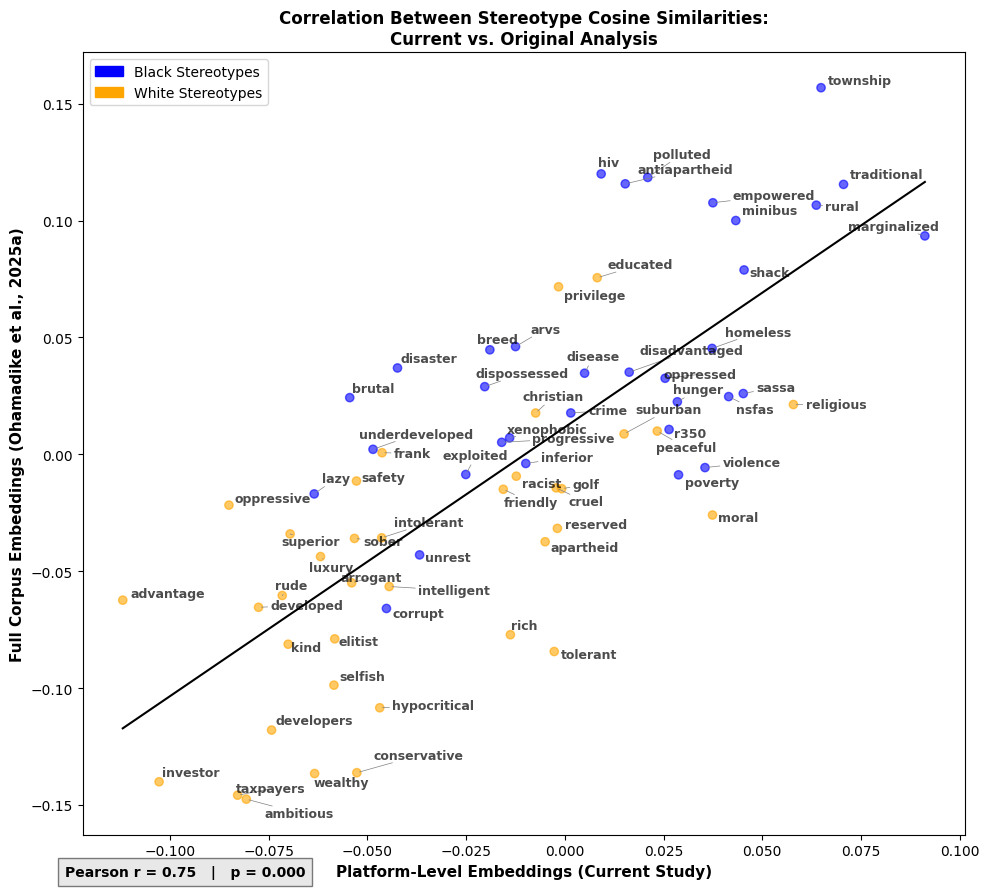


Plot saved to: /content/drive/MyDrive/vaccine data/cosine_similarity_cross_analysis_correlation.png


In [6]:
## Correlation between the associations in the present study and Ohamadike et al. (2025)

!pip install adjustText
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from adjustText import adjust_text
import matplotlib.patches as mpatches

# ── Load current analysis scores ──────────────────────────────────────────────
current_path = '/content/drive/MyDrive/vaccine data/stereotype_cosine_similarity_platform_resampled_socioeconomic_100.xlsx'
current_data = pd.read_excel(current_path)

# ── Load original analysis scores ─────────────────────────────────────────────
original_path = '/content/drive/My Drive/adjective_cosine_similarity_new1.xlsx'
original_data = pd.read_excel(original_path)

# ── Merge on stereotype name ───────────────────────────────────────────────────
# Keep only stereotypes present in the CURRENT analysis
# Original file has 'Adjective' and 'Mean Similarity' columns
merged = current_data.merge(
    original_data[['Adjective', 'Mean Similarity']],
    left_on='Stereotype',
    right_on='Adjective',
    how='inner'
).dropna(subset=['Mean Cosine Similarity', 'Mean Similarity'])

print(f"Stereotypes in current analysis:         {len(current_data)}")
print(f"Stereotypes retained after merge:        {len(merged)}")
print(f"Dropped (not in original analysis):      "
      f"{set(current_data['Stereotype']) - set(merged['Stereotype'])}")

# ── Correlation ────────────────────────────────────────────────────────────────
correlation, p_value = pearsonr(
    merged['Mean Cosine Similarity'],
    merged['Mean Similarity']
)
print(f"\nPearson r = {correlation:.3f}, p = {p_value:.4f}")

# ── Colour-code by category ────────────────────────────────────────────────────
colors = [
    'orange' if row['Category'] == 'White' else 'blue'
    for _, row in merged.iterrows()
]

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 9))

plt.scatter(
    merged['Mean Cosine Similarity'],
    merged['Mean Similarity'],
    c=colors, alpha=0.6
)

# Regression line
m, b = np.polyfit(merged['Mean Cosine Similarity'], merged['Mean Similarity'], 1)
x_line = np.linspace(merged['Mean Cosine Similarity'].min(),
                     merged['Mean Cosine Similarity'].max(), 200)
plt.plot(x_line, m * x_line + b, color='black')

# Annotations
texts = []
for _, row in merged.iterrows():
    texts.append(plt.text(
        row['Mean Cosine Similarity'],
        row['Mean Similarity'],
        row['Stereotype'],
        fontsize=9, fontweight='bold', alpha=0.7
    ))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Labels and formatting
plt.xlabel("Platform-Level Embeddings (Current Study)",
           fontweight='bold', fontsize=11)
plt.ylabel("Full Corpus Embeddings (Ohamadike et al., 2025a)",
           fontweight='bold', fontsize=11)
plt.title("Correlation Between Stereotype Cosine Similarities:\nCurrent vs. Original Analysis",
          fontweight='bold', fontsize=12)

plt.figtext(
    0.07, 0.02,
    f"Pearson r = {correlation:.2f}   |   p = {p_value:.3f}",
    fontsize=10, fontweight='bold',
    bbox={"facecolor": "lightgrey", "alpha": 0.5, "pad": 5}
)

blue_patch   = mpatches.Patch(color='blue',   label='Black Stereotypes')
orange_patch = mpatches.Patch(color='orange', label='White Stereotypes')
plt.legend(handles=[blue_patch, orange_patch], loc='upper left')

plt.tight_layout()

# Save
save_path = '/content/drive/MyDrive/vaccine data/cosine_similarity_cross_analysis_correlation.png'
plt.savefig(save_path, bbox_inches='tight', dpi=700)
plt.show()

print(f"\nPlot saved to: {save_path}")


Unique source tokens found across all runs: 39
Platforms present in ≥5 run embeddings: 39
Eligible platforms: ['source_africa_newsroom', 'source_bhekisisa', 'source_biz_community', 'source_business_day', 'source_business_tech', 'source_cape_argus', 'source_cape_times', 'source_channel_africa', 'source_city_press', 'source_daily_dispatch', 'source_daily_maverick', 'source_daily_news', 'source_daily_sun', 'source_enca_online', 'source_engineering_news', 'source_eyewitness_news', 'source_fin24', 'source_financial_mail', 'source_huffington_post', 'source_iol', 'source_m_g', 'source_mining_weekly', 'source_moneyweb', 'source_my_broadband', 'source_news24', 'source_politicsweb', 'source_pretoria_news', 'source_sa_news', 'source_sabc_online_news', 'source_saturday_star', 'source_sowetan', 'source_sunday_world', 'source_the_citizen', 'source_the_conversation', 'source_the_herald', 'source_the_mercury', 'source_the_star', 'source_the_times', 'source_weekend_argus']

=== STEREOTYPE EXCLUSIONS (

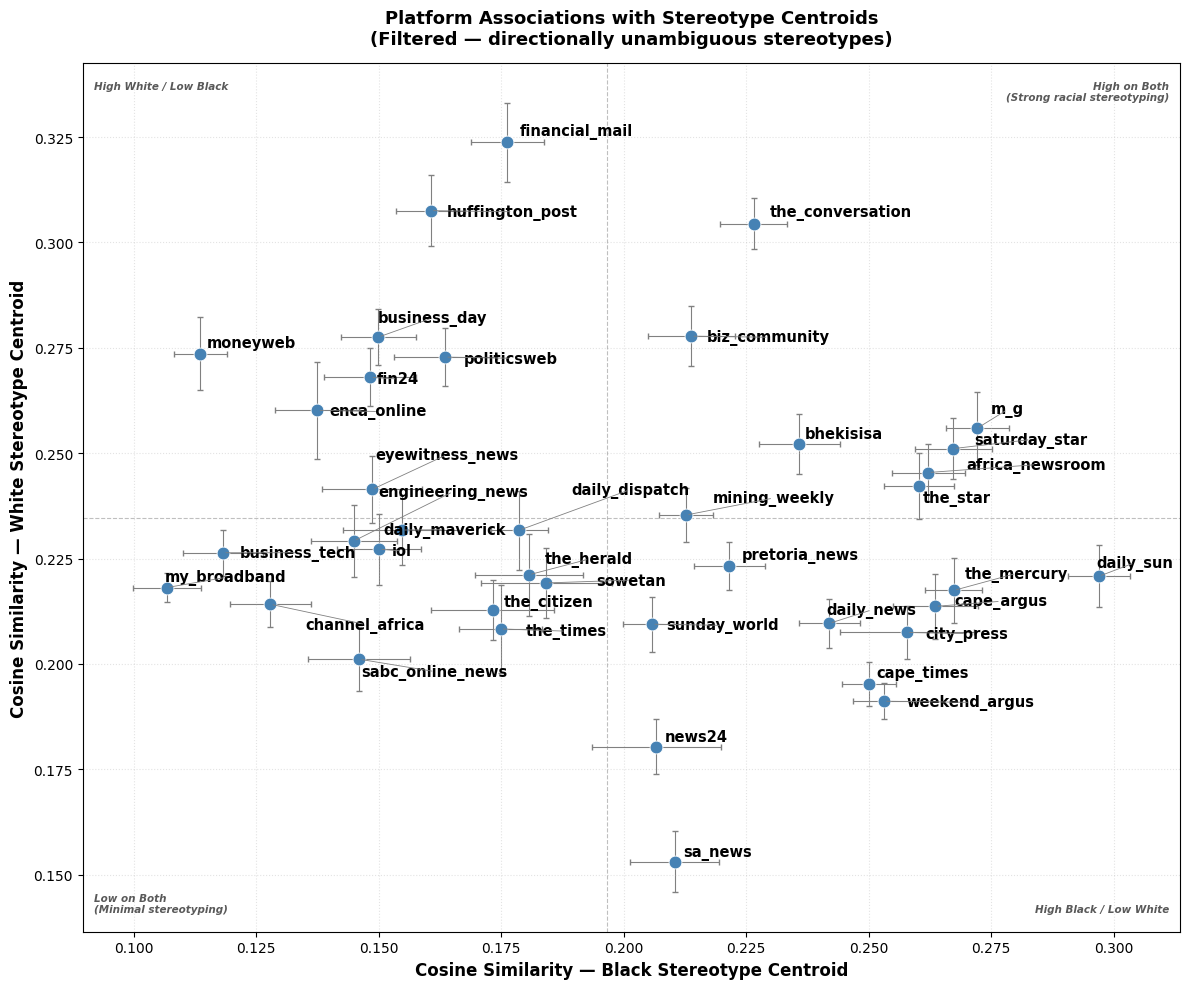

Plot saved → /content/drive/MyDrive/vaccine data/platform_scatter_filtered_100.png


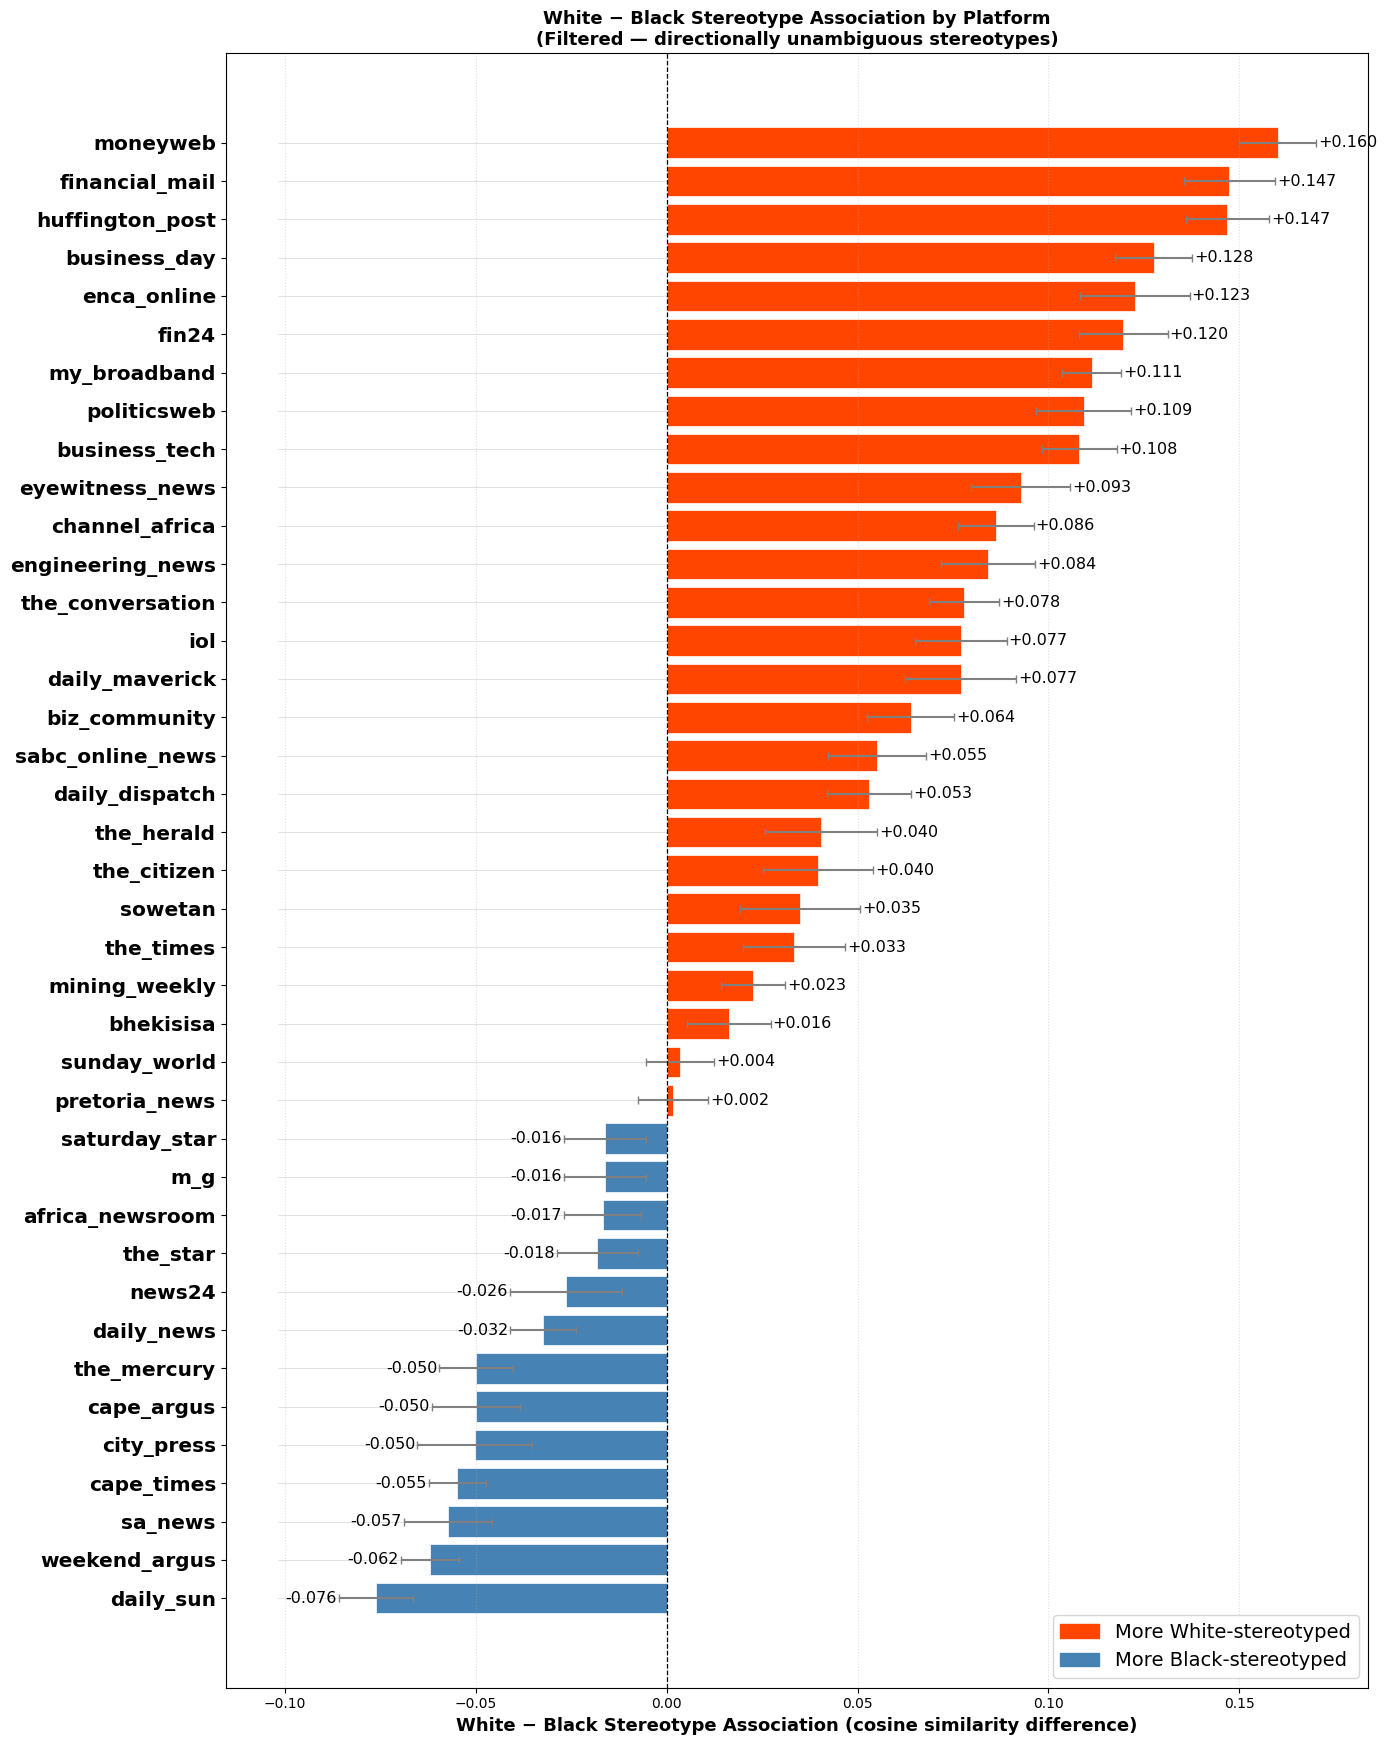

Plot saved → /content/drive/MyDrive/vaccine data/platform_bar_filtered_100.png


In [7]:
## Scatterplot of association between platforms and stereotypes (100 cap)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from gensim.models import KeyedVectors
from scipy.stats import permutation_test
from collections import defaultdict

# ─── 1. Stereotype lists (unchanged from Ohamadike et al., 2025) ──────────────
white_stereotypes = [
    "racist", "rude", "arrogant", "selfish", "wealthy", "oppressive",
    "prejudiced", "frank", "cultured", "friendly", "kind", "educated",
    "tolerant", "intelligent", "hypocritical", "advantage", "christian", "intolerant",
    "hospitable", "religious", "conservative", "reserved", "privilege", "exploitative",
    "estates", "elitist", "peaceful", "golf", "rich",
    "luxury", "sheltered", "apartheid", "ambitious", "investor", "developed",
    "sober", "safety", "suburban", "superior", "taxpayers", "landowners",
    "developers", "cruel", "moral"
]

black_stereotypes = [
    "underdeveloped", "violence", "crime", "polluted", "disadvantaged",
    "traditional", "empowered", "uneducated", "oppressed", "marginalized",
    "lazy", "rural", "corrupt", "shack", "township", "minibus",
    "hiv", "xenophobic", "looter", "alcoholism", "poverty", "exploited", "unrest",
    "nsfas", "sassa", "spaza", "homeless", "discriminated",
    "antiapartheid", "gardener", "arvs", "nyaope", "dispossessed", "inferior",
    "leech", "brutal", "barbaric", "squalor", "hunger", "r350", "progressive",
    "breed", "disease", "disaster"
]

all_stereotypes = white_stereotypes + black_stereotypes

race_groups = {
    "black_group":  ["black", "blacks", "african", "afro", "indigenous", "zulu"],
    "white_group":  ["white", "whites", "european", "american", "anglo", "settler", "afrikaner"]
}

MIN_RUNS = 5  # stereotype must appear in ≥5 runs to be included

# ─── 3. Extract source_ tokens from training data ─────────────────────────────
# Each file line: <source_token> <text...>
# We collect the unique source_ tokens that appear in any run.

all_source_tokens = set()
source_token_run_counts = defaultdict(int)  # how many runs each token appears in

for run in range(1, n_runs + 1):
    path = f"/content/drive/MyDrive/vaccine data/SA_vaccine-total-news_training-data-platform_100_run{run}.txt"
    run_tokens = set()
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(" ", 1)
            if parts:
                token = parts[0]
                run_tokens.add(token)
    all_source_tokens.update(run_tokens)
    for tok in run_tokens:
        source_token_run_counts[tok] += 1

print(f"\nUnique source tokens found across all runs: {len(all_source_tokens)}")

# Keep only tokens that appear in the vocabulary of ≥MIN_RUNS embeddings
eligible_platforms = []
for tok in sorted(all_source_tokens):
    n_present = sum(1 for m in models if tok in m)
    if n_present >= MIN_RUNS:
        eligible_platforms.append(tok)

print(f"Platforms present in ≥{MIN_RUNS} run embeddings: {len(eligible_platforms)}")
print("Eligible platforms:", eligible_platforms)

# ─── 4. Race-dimension bias direction ─────────────────────────────────────────
def compute_centroid(words, models):
    """Average vector across all runs for the given word list."""
    vecs = [m[w] for m in models for w in words if w in m]
    if not vecs:
        raise ValueError(f"None of {words} found in any model.")
    return np.mean(vecs, axis=0)

black_centroid_race = compute_centroid(race_groups["black_group"], models)
white_centroid_race = compute_centroid(race_groups["white_group"], models)
raw_direction  = black_centroid_race - white_centroid_race
bias_direction = raw_direction / np.linalg.norm(raw_direction)   # unit vector: → Black

# ─── 5. Per-stereotype cosine similarities onto bias direction ────────────────
def cosine_sim(vec, direction):
    norm_v = np.linalg.norm(vec)
    norm_d = np.linalg.norm(direction)
    if norm_v == 0 or norm_d == 0:
        return np.nan
    return np.dot(vec, direction) / (norm_v * norm_d)

stereotype_scores = {}   # word → np.array of per-run cosine sims
excluded = {"too_rare": [], "all_missing": []}

for word in all_stereotypes:
    run_sims = [cosine_sim(m[word], bias_direction) for m in models if word in m]
    n = len(run_sims)
    if n == 0:
        excluded["all_missing"].append(word)
    elif n < MIN_RUNS:
        excluded["too_rare"].append((word, n))
    else:
        stereotype_scores[word] = np.array(run_sims)

print(f"\n=== STEREOTYPE EXCLUSIONS (threshold ≥{MIN_RUNS} runs) ===")
print(f"Missing from all runs:  {excluded['all_missing']}")
print(f"Too rare (<{MIN_RUNS} runs): {[w for w, _ in excluded['too_rare']]}")
print(f"Retained: {len(stereotype_scores)}/{len(all_stereotypes)} terms")

stereotype_means = {w: scores.mean() for w, scores in stereotype_scores.items()}

# ─── 6. Analysis A — ALL stereotypes: compute White & Black centroids ─────────
# For each stereotype in each run: compute its embedding vector,
# then average across runs → one stable centroid per stereotype group.

def compute_stereotype_centroid_per_run(wordlist, models):
    """
    Returns a centroid per run (averaged over whichever words are present),
    and a global centroid (averaged over all runs × words).
    """
    per_run = []
    for m in models:
        vecs = [m[w] for w in wordlist if w in m]
        if vecs:
            per_run.append(np.mean(vecs, axis=0))
    if not per_run:
        raise ValueError("No stereotype words found in any model.")
    global_centroid = np.mean(per_run, axis=0)
    return per_run, global_centroid

white_stereo_per_run, white_stereo_centroid = compute_stereotype_centroid_per_run(
    white_stereotypes, models)
black_stereo_per_run, black_stereo_centroid = compute_stereotype_centroid_per_run(
    black_stereotypes, models)

# ─── 7. Analysis B — CORRECTED FILTER ────────────────────────────────────────
# Black stereotypes: mean cosine sim > 0  (project toward Black pole)
# White stereotypes: mean cosine sim < 0  (project toward White pole)
# No percentile threshold — all directionally consistent terms are included.

filtered_black = [w for w in black_stereotypes
                  if w in stereotype_means and stereotype_means[w] > 0]
filtered_white = [w for w in white_stereotypes
                  if w in stereotype_means and stereotype_means[w] < 0]

print(f"=== ANALYSIS B FILTER (corrected) ===")
print(f"Black stereotypes with mean cosine sim > 0  ({len(filtered_black)}): {filtered_black}")
print(f"White stereotypes with mean cosine sim < 0  ({len(filtered_white)}): {filtered_white}")

# Sanity check: report any stereotypes that project to the WRONG side
wrong_black = [w for w in black_stereotypes
               if w in stereotype_means and stereotype_means[w] <= 0]
wrong_white = [w for w in white_stereotypes
               if w in stereotype_means and stereotype_means[w] >= 0]
print(f"\nBlack stereotypes projecting to White side (excluded): {wrong_black}")
print(f"White stereotypes projecting to Black side (excluded): {wrong_white}")

white_stereo_filt_per_run, white_stereo_filt_centroid = compute_stereotype_centroid_per_run(
    filtered_white, models)
black_stereo_filt_per_run, black_stereo_filt_centroid = compute_stereotype_centroid_per_run(
    filtered_black, models)

# ─── 8. Platform association scores ──────────────────────────────────────────
# For each platform token, for each run where it appears:
#   sim_white = cosine_sim(platform_vec, white_stereo_centroid_of_that_run)
#   sim_black = cosine_sim(platform_vec, black_stereo_centroid_of_that_run)
# Then average across runs.

def compute_platform_scores(platforms, models,
                             white_per_run, black_per_run,
                             label=""):
    """
    Returns a dict: platform → {
        'white_mean', 'white_se',
        'black_mean', 'black_se',
        'n_runs'
    }
    """
    results = {}
    for tok in platforms:
        white_sims, black_sims = [], []
        for i, m in enumerate(models):
            if tok not in m:
                continue
            pvec = m[tok]
            if i < len(white_per_run):
                ws = cosine_sim(pvec, white_per_run[i])
                bs = cosine_sim(pvec, black_per_run[i])
                if not (np.isnan(ws) or np.isnan(bs)):
                    white_sims.append(ws)
                    black_sims.append(bs)
        n = len(white_sims)
        if n == 0:
            continue
        results[tok] = {
            "white_mean": np.mean(white_sims),
            "white_se":   np.std(white_sims) / np.sqrt(n),
            "black_mean": np.mean(black_sims),
            "black_se":   np.std(black_sims) / np.sqrt(n),
            "n_runs":     n
        }
    print(f"\n{label}: Scored {len(results)}/{len(platforms)} platforms")
    return results

scores_all      = compute_platform_scores(
    eligible_platforms, models,
    white_stereo_per_run, black_stereo_per_run,
    label="Analysis A (all stereotypes)")

scores_filtered = compute_platform_scores(
    eligible_platforms, models,
    white_stereo_filt_per_run, black_stereo_filt_per_run,
    label="Analysis B (filtered stereotypes)")

# ─── 9. Export to Excel ───────────────────────────────────────────────────────
def scores_to_df(scores_dict, label):
    rows = []
    for tok, s in sorted(scores_dict.items(),
                          key=lambda x: x[1]["white_mean"] - x[1]["black_mean"]):
        rows.append({
            "Platform":                   tok,
            "White_Stereo_Mean_CosSim":   round(s["white_mean"], 4),
            "White_Stereo_SE":            round(s["white_se"],   4),
            "Black_Stereo_Mean_CosSim":   round(s["black_mean"], 4),
            "Black_Stereo_SE":            round(s["black_se"],   4),
            "White_minus_Black":          round(s["white_mean"] - s["black_mean"], 4),
            "N_Runs":                     s["n_runs"],
            "Analysis":                   label
        })
    return pd.DataFrame(rows)

df_all      = scores_to_df(scores_all,      "All stereotypes")
df_filtered = scores_to_df(scores_filtered, "Filtered stereotypes")
df_combined = pd.concat([df_all, df_filtered], ignore_index=True)

out_xlsx = "/content/drive/MyDrive/vaccine data/platform_racism_scores_100.xlsx"
with pd.ExcelWriter(out_xlsx) as writer:
    df_all.to_excel(writer,      sheet_name="All_stereotypes",      index=False)
    df_filtered.to_excel(writer, sheet_name="Filtered_stereotypes", index=False)
    df_combined.to_excel(writer, sheet_name="Combined",             index=False)
print(f"\nResults saved → {out_xlsx}")

# ─── 10. UPDATED scatter plot with adjustText ─────────────────────────────────
# Install once in your Colab session:
#   !pip install adjustText

from adjustText import adjust_text

def plot_platform_scatter(scores_dict, title, save_path):
    """
    Scatter plot: x = Black stereotype association,
                  y = White stereotype association.
    Labels are de-overlapped using adjustText.
    """
    fig, ax = plt.subplots(figsize=(12, 10))

    platforms = list(scores_dict.keys())
    xs = np.array([scores_dict[p]["black_mean"] for p in platforms])
    ys = np.array([scores_dict[p]["white_mean"] for p in platforms])
    xe = np.array([scores_dict[p]["black_se"]   for p in platforms])
    ye = np.array([scores_dict[p]["white_se"]   for p in platforms])

    # Quadrant dividers at cross-run means
    x_mid = xs.mean()
    y_mid = ys.mean()
    ax.axvline(x_mid, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axhline(y_mid, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)

    # Error bars (drawn first, behind points)
    ax.errorbar(xs, ys, xerr=xe, yerr=ye,
                fmt='none', ecolor='gray', elinewidth=0.8,
                capsize=2, zorder=1)

    # Points
    ax.scatter(xs, ys, s=85, c='steelblue', zorder=3,
               edgecolors='white', linewidths=0.6)

    # Labels — collect first, then adjust
    labels = [p.replace("source_", "") for p in platforms]
    texts = [
        ax.text(xs[i], ys[i], labels[i], fontsize=10.5, fontweight='bold')
        for i in range(len(platforms))
    ]

    # adjustText: nudge labels apart, draw arrows back to points
    adjust_text(
        texts,
        x=xs, y=ys,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.6),
        expand_points=(1.6, 1.6),
        expand_text=(1.4, 1.4),
        force_points=(0.4, 0.4),
        force_text=(0.6, 0.6),
        only_move={'points': 'xy', 'texts': 'xy'},
    )

    ax.set_xlabel("Cosine Similarity — Black Stereotype Centroid",
                  fontweight='bold', fontsize=12)
    ax.set_ylabel("Cosine Similarity — White Stereotype Centroid",
                  fontweight='bold', fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=13, pad=14)
    ax.grid(True, linestyle=':', alpha=0.35)

    # Quadrant corner annotations
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    kw = dict(fontsize=7.5, color='black', style='italic', alpha=0.65, fontweight='bold')
    pad_x = 0.01 * (xlim[1] - xlim[0])
    pad_y = 0.02 * (ylim[1] - ylim[0])
    ax.text(xlim[0] + pad_x, ylim[1] - pad_y,
            "High White / Low Black", ha='left', va='top', **kw)
    ax.text(xlim[1] - pad_x, ylim[1] - pad_y,
            "High on Both\n(Strong racial stereotyping)", ha='right', va='top', **kw)
    ax.text(xlim[0] + pad_x, ylim[0] + pad_y,
            "Low on Both\n(Minimal stereotyping)", ha='left', va='bottom', **kw)
    ax.text(xlim[1] - pad_x, ylim[0] + pad_y,
            "High Black / Low White", ha='right', va='bottom', **kw)

    plt.tight_layout()
    plt.savefig(save_path, dpi=500, bbox_inches='tight')
    plt.show()
    print(f"Plot saved → {save_path}")

# ─── 11. Bar plot: White–Black difference score ───────────────────────────────
def plot_difference_bar(scores_dict, title, save_path):
    """
    Horizontal bar: White_mean − Black_mean per platform.
    Positive = more White-stereotype association;
    Negative = more Black-stereotype association.
    """
    platforms = sorted(scores_dict.keys(),
                        key=lambda p: scores_dict[p]["white_mean"] - scores_dict[p]["black_mean"])
    diffs = [scores_dict[p]["white_mean"] - scores_dict[p]["black_mean"]
             for p in platforms]
    ses   = [np.sqrt(scores_dict[p]["white_se"]**2 + scores_dict[p]["black_se"]**2)
             for p in platforms]

    colors = ['orangered' if d > 0 else 'steelblue' for d in diffs]
    labels = [p.replace("source_", "") for p in platforms]

    fig, ax = plt.subplots(figsize=(14, max(6, len(platforms) * 0.45)))
    bars = ax.barh(range(len(platforms)), diffs, color=colors,
                   xerr=ses, error_kw=dict(ecolor='gray', capsize=3),
                   edgecolor='white', linewidth=0.5)

    xmin = min(diffs) - max(ses) - 0.01
    for y in range(len(platforms)):
      ax.hlines(
        y=y,
        xmin=xmin,
        xmax=diffs[y],
        color='#cccccc',
        linewidth=0.7,
        alpha=0.6,
        zorder=0
    )

    ax.set_yticks(range(len(platforms)))
    ax.set_yticklabels(labels, fontsize=14.5, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
    ax.set_xlabel("White − Black Stereotype Association (cosine similarity difference)",
                  fontweight='bold', fontsize=13)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.grid(axis='x', linestyle=':', alpha=0.4)

    # Value annotations
    for i, (d, se) in enumerate(zip(diffs, ses)):
        ax.annotate(f"{d:+.3f}",
                    (d + np.sign(d) * (se + 0.0005), i),
                    ha='left' if d >= 0 else 'right',
                    va='center', fontsize=11.5)

    # Legend
    patch_w = mpatches.Patch(color='orangered',  label='More White-stereotyped')
    patch_b = mpatches.Patch(color='steelblue',  label='More Black-stereotyped')
    ax.legend(handles=[patch_w, patch_b], fontsize=14, loc='lower right')

    plt.tight_layout()
    plt.savefig(save_path, dpi=500, bbox_inches='tight')
    plt.show()
    print(f"Plot saved → {save_path}")

# ─── 12. Generate all plots ────────────────────────────────────────────────────
base = "/content/drive/MyDrive/vaccine data/"

# Analysis B
plot_platform_scatter(
    scores_filtered,
    "Platform Associations with Stereotype Centroids\n(Filtered — directionally unambiguous stereotypes)",
    base + "platform_scatter_filtered_100.png"
)
plot_difference_bar(
    scores_filtered,
    "White − Black Stereotype Association by Platform\n(Filtered — directionally unambiguous stereotypes)",
    base + "platform_bar_filtered_100.png"
)